<a href="https://colab.research.google.com/github/dhanush78945-afk/Assignment1-AIML/blob/main/area.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [ ]:
import pandas as pd

# Construct the full path to the CSV file within the downloaded directory
dataset_path = f"{path}/creditcard.csv"

# Load the dataset into a pandas DataFrame
df = pd.read_csv(dataset_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Display a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
# Check for missing values
display(df.isnull().sum())

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
# Check the distribution of the target variable 'Class'
display(df['Class'].value_counts())
display(df['Class'].value_counts(normalize=True) * 100)

,count
Class,
0,284315
1,492


,proportion
Class,
0,99.827251
1,0.172749


In [ ]:
from sklearn.preprocessing import StandardScaler

# Drop the 'Time' column as it's not directly useful for classification
df = df.drop('Time', axis=1)

# Scale the 'Amount' column
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

display(df.head())

KeyError: "['Time'] not found in axis"

In [ ]:
# Check the distribution of the target variable 'Class'
display(df['Class'].value_counts())
display(df['Class'].value_counts(normalize=True) * 100)

,count
Class,
0,284315
1,492


,proportion
Class,
0,99.827251
1,0.172749


In [ ]:
from sklearn.preprocessing import StandardScaler

# Drop the 'Time' column as it's not directly useful for classification
df = df.drop('Time', axis=1)

# Scale the 'Amount' column
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

display(df.head())

KeyError: "['Time'] not found in axis"

In [ ]:
# Check the distribution of the target variable 'Class'
display(df['Class'].value_counts())
display(df['Class'].value_counts(normalize=True) * 100)

,count
Class,
0,284315
1,492


,proportion
Class,
0,99.827251
1,0.172749


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("\nDistribution of 'Class' in y_resampled:")
display(y_resampled.value_counts())
print("\nDistribution of 'Class' in y_train:")
display(y_train.value_counts())
print("\nDistribution of 'Class' in y_test:")
display(y_test.value_counts())

Shape of X_train: (398041, 29)
Shape of X_test: (170589, 29)
Shape of y_train: (398041,)
Shape of y_test: (170589,)

Distribution of 'Class' in y_resampled:


,count
Class,
0,284315
1,284315



Distribution of 'Class' in y_train:


,count
Class,
1,199021
0,199020



Distribution of 'Class' in y_test:


,count
Class,
0,85295
1,85294


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train models
models = {
    'Linear SVC': LinearSVC(random_state=42, dual=False, max_iter=10000), # Set dual=False for n_samples > n_features
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', max_iter=1000),
    'Random Forest Classifier': RandomForestClassifier(random_state=42),
    'Decision Tree Classifier': DecisionTreeClassifier(random_state=42)
}

for name, model in models.items():
    print(f"\n----- Training {name} -----")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy Score for {name}: {accuracy_score(y_test, y_pred):.4f}")


----- Training Linear SVC -----

Classification Report for Linear SVC:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     85295
           1       0.98      0.91      0.94     85294

    accuracy                           0.94    170589
   macro avg       0.95      0.94      0.94    170589
weighted avg       0.95      0.94      0.94    170589

Accuracy Score for Linear SVC: 0.9427

----- Training Logistic Regression -----

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95     85295
           1       0.97      0.92      0.94     85294

    accuracy                           0.95    170589
   macro avg       0.95      0.95      0.95    170589
weighted avg       0.95      0.95      0.95    170589

Accuracy Score for Logistic Regression: 0.9460

----- Training Random Forest Classifier -----

Classification Report for Random Forest Classifier:

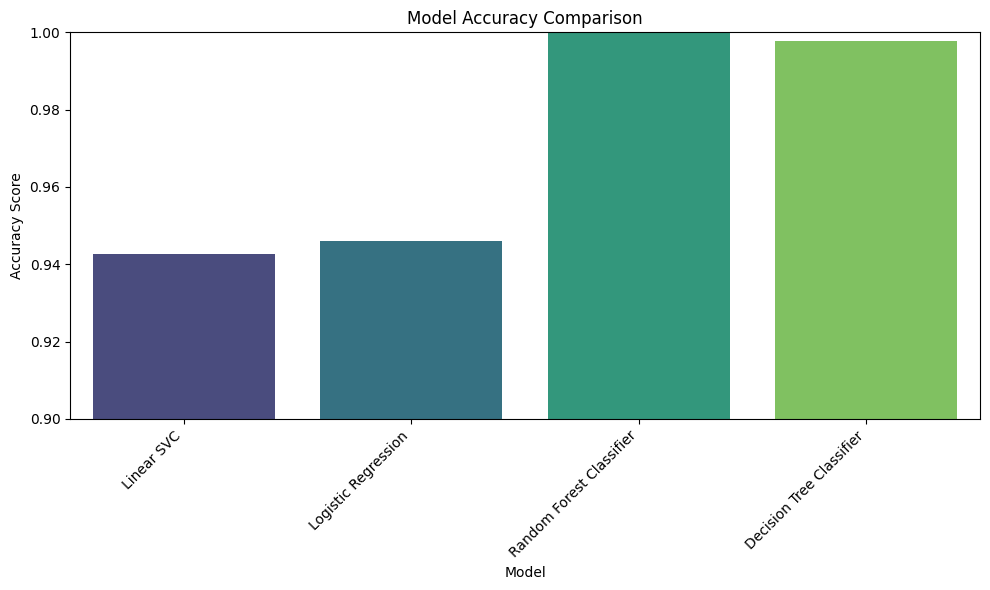

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionary to store accuracy scores
accuracy_scores = {}

# Re-calculate accuracy scores for each model
for name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy_scores[name] = accuracy_score(y_test, y_pred)

# Convert to a pandas Series for easy plotting
accuracy_series = pd.Series(accuracy_scores)

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=accuracy_series.index, y=accuracy_series.values, hue=accuracy_series.index, palette='viridis', legend=False)
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0.90, 1.0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()